# **Pneumonia Classification Using ResNet-18**

### **In this notebook:**

- **Chest X-rays** are classified into two categories: **NORMAL** and **PNEUMONIA**.
- The objective is to fine-tune a **pre-trained ResNet-18** model for efficient and accurate classification.
- Lastly visualize the predictions along with the **class probabilities** for interpretability.

### **Hardware Information**
- **Device Name:** NVIDIA GeForce GTX 1050 Ti
- Utilized on a **local system** to speed up the training and inference process.

### **Goal**
Achieve a robust model for **medical image classification** to aid in the diagnosis of pneumonia for demonstration purposes.


In [5]:
# Import Required Libraries
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, f1_score
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt



# Set Device (GPU or CPU) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# Enable cuDNN Benchmark for Optimized Performance (if using GPU)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# Clear GPU Cache 
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Monitor GPU Memory 
if torch.cuda.is_available():
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Cached GPU memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# Set Random Seed for Reproducibility
torch.manual_seed(101010)
np.random.seed(101010)
random.seed(101010)

# Data Preprocessing and Loading
transform_mean = [0.485, 0.456, 0.406]
transform_std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=transform_mean, std=transform_std)
])

train_path = 'D:/chest_xray/chest_xray/chest_xray/train'
test_path = 'D:/chest_xray/chest_xray/chest_xray/test'

train_dataset = ImageFolder(train_path, transform=transform)
test_dataset = ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=4)

# Load and Adjust ResNet-18 Model
resnet18 = models.resnet18(pretrained=True)
for param in resnet18.parameters():
    param.requires_grad = False

num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 1)
resnet18 = resnet18.to(device)

# Define Loss Function and Optimizer
#criterion = nn.CrossEntropyLoss()  # For multi-class classification
criterion = nn.BCEWithLogitsLoss() # For Binary Classification
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Initialize Mixed Precision Scaler for AMP
scaler = torch.cuda.amp.GradScaler()

# Train the Model
num_epochs = 3
for epoch in range(num_epochs):
    resnet18.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        #if torch.cuda.is_available():
            #print(f"Before training step - Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
        
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    
        #if torch.cuda.is_available():
            #print(f"After training step - Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

    scheduler.step()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.4f}")

# Evaluate the Model
resnet18.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
test_f1_score = f1_score(all_labels, all_preds, average='weighted')
print(f"Test Accuracy: {test_accuracy:.3f}, F1 Score: {test_f1_score:.3f}")

#if torch.cuda.is_available():
    #print(f"Final Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
   # print(f"Final Cached GPU memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")



Using device: cuda
CUDA Available: True
Device Name: GeForce GTX 1050 Ti
Allocated GPU memory: 51.89 MB
Cached GPU memory: 64.00 MB
Epoch 1, Loss: 0.4807
Epoch 2, Loss: 0.3329
Epoch 3, Loss: 0.2783
Test Accuracy: 0.801, F1 Score: 0.784


In [2]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Device Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


CUDA Available: True
PyTorch Version: 1.10.2+cu102
CUDA Version: 10.2
Device Name: GeForce GTX 1050 Ti


In [3]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")


CUDA Available: True
Device Name: GeForce GTX 1050 Ti


In [5]:
import torch
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


CUDA Available: False
Using device: cpu


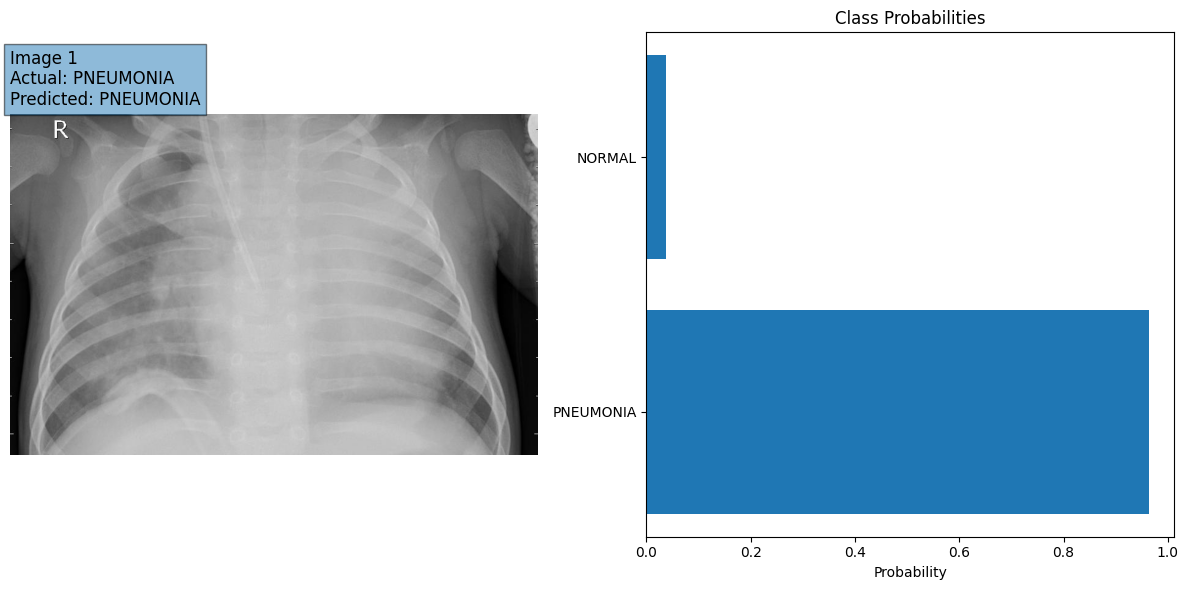

Image 1:
  Actual class: PNEUMONIA
  Predicted class: PNEUMONIA
  Class Probabilities: {'NORMAL': 0.03671562671661377, 'PNEUMONIA': 0.9632843732833862}
------------------------------


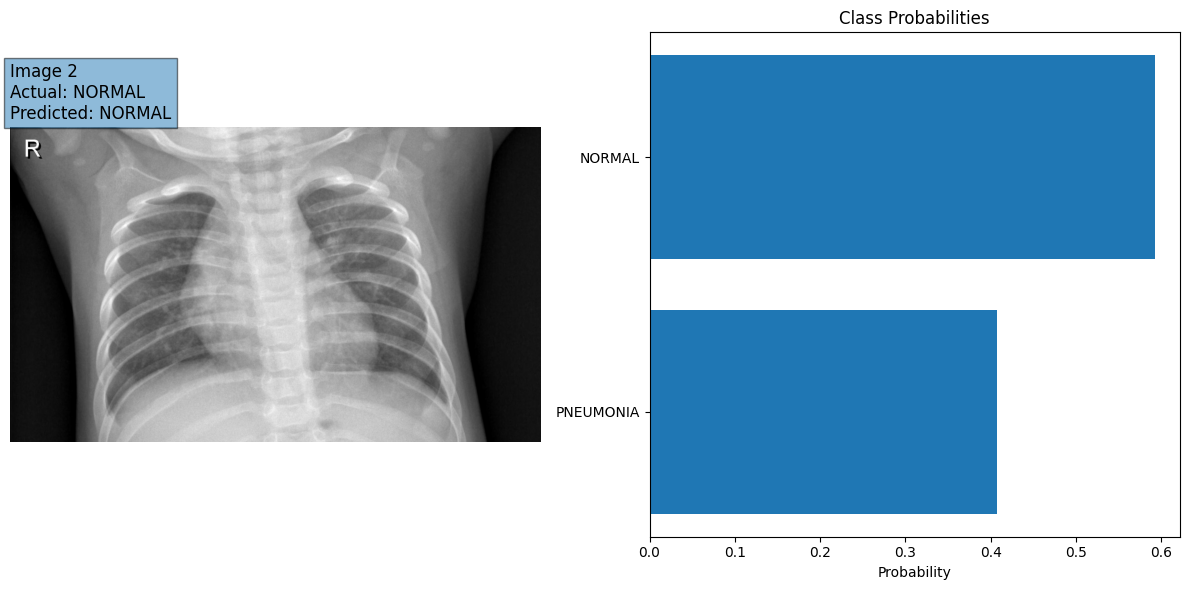

Image 2:
  Actual class: NORMAL
  Predicted class: NORMAL
  Class Probabilities: {'NORMAL': 0.5924038290977478, 'PNEUMONIA': 0.4075961709022522}
------------------------------


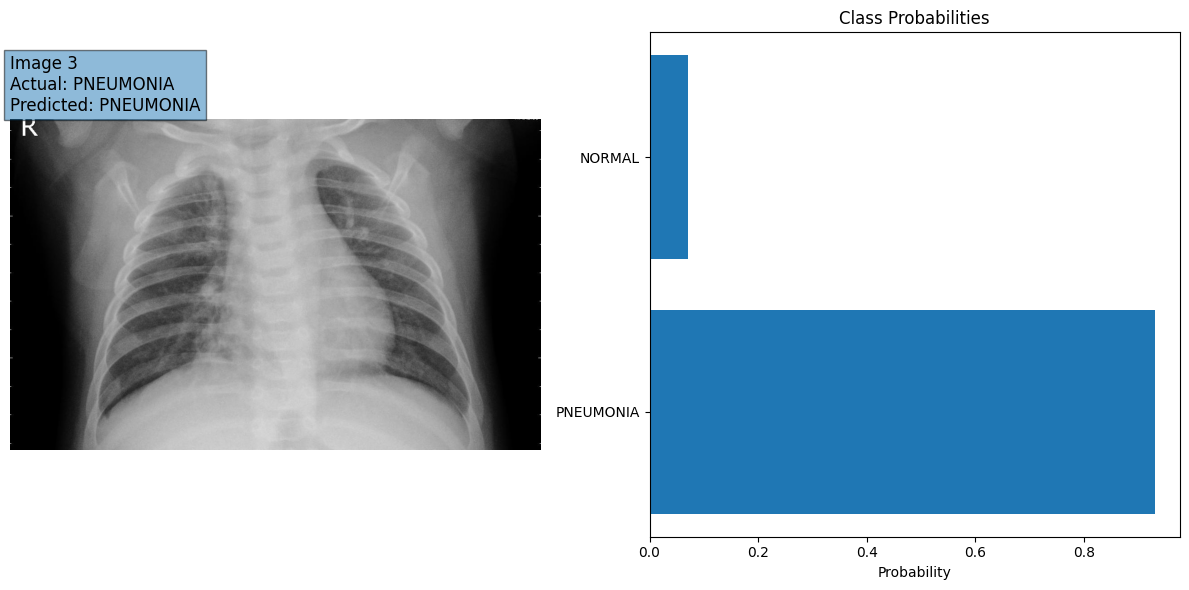

Image 3:
  Actual class: PNEUMONIA
  Predicted class: PNEUMONIA
  Class Probabilities: {'NORMAL': 0.0699915885925293, 'PNEUMONIA': 0.9300084114074707}
------------------------------


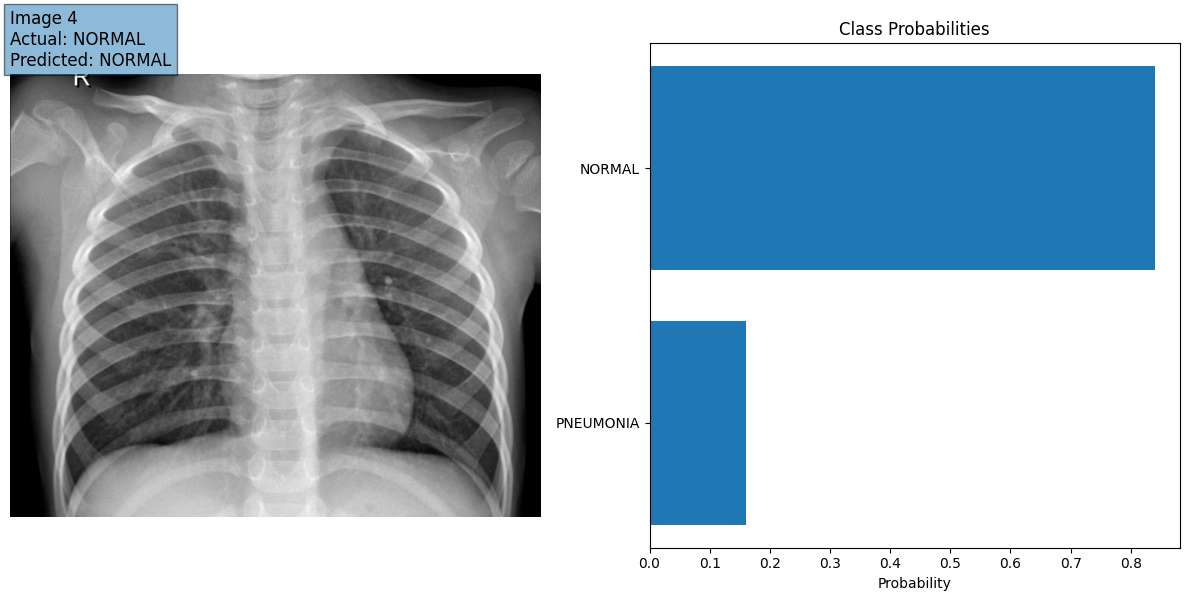

Image 4:
  Actual class: NORMAL
  Predicted class: NORMAL
  Class Probabilities: {'NORMAL': 0.839924156665802, 'PNEUMONIA': 0.160075843334198}
------------------------------


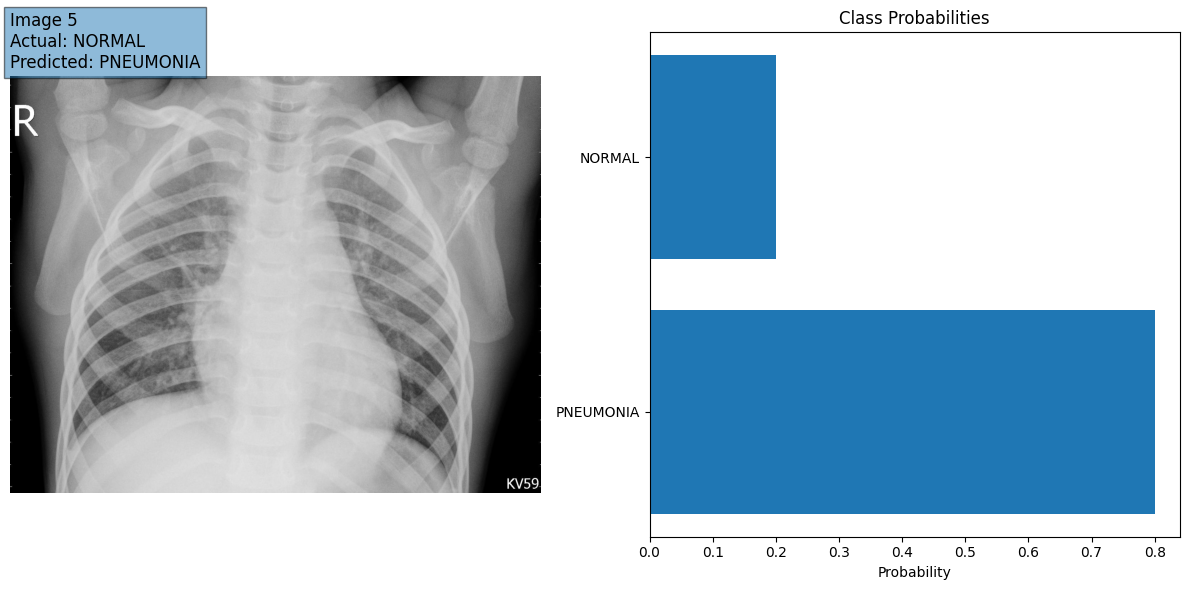

Image 5:
  Actual class: NORMAL
  Predicted class: PNEUMONIA
  Class Probabilities: {'NORMAL': 0.19985896348953247, 'PNEUMONIA': 0.8001410365104675}
------------------------------


In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, transform):
    """
    Loads an image from the specified path, converts it to RGB format, applies transformations, 
    and prepares it as a tensor for model input.
    
    Args:
        image_path (str): The file path of the image to load.
        transform (torchvision.transforms.Compose): Transformations to apply to the image.
        
    Returns:
        tuple: Original PIL image and preprocessed image tensor ready for model input.
    """
    image = Image.open(image_path).convert("RGB")  # Open and convert image to RGB
    return image, transform(image).unsqueeze(0)     # Apply transformations and add batch dimension

def predict_image(model, image_path, transform, device):
    """
    Loads and preprocesses an image, then uses the model to predict class probabilities.
    
    Args:
        model (torch.nn.Module): Trained model to use for prediction.
        image_path (str): Path to the image file to predict.
        transform (torchvision.transforms.Compose): Transformations to apply to the image.
        device (torch.device): Device to run the model on (CPU or GPU).
        
    Returns:
        tuple: Original image and class probabilities as a dictionary.
    """
    original_image, image_tensor = load_and_preprocess_image(image_path, transform)  # Load and preprocess image
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation for inference
        image_tensor = image_tensor.to(device)  # Move image tensor to specified device
        output = model(image_tensor)           # Get model output (logit)
        probability_pneumonia = torch.sigmoid(output).item()  # Convert logit to probability for 'PNEUMONIA'
        probability_normal = 1 - probability_pneumonia        # Derive probability for 'NORMAL'

    return original_image, {"NORMAL": probability_normal, "PNEUMONIA": probability_pneumonia}


# Visualization function for predictions
def visualize_predictions(image, probabilities, class_names, actual_class, predicted_class, image_index):
    """
    Displays the original image alongside a bar chart of class probabilities.
    
    Args:
        image (PIL.Image): The original image.
        probabilities (dict): Dictionary of class probabilities output by the model.
        class_names (list): List of class names corresponding to model output.
        actual_class (str): The actual class of the image.
        predicted_class (str): The predicted class of the image.
        image_index (int): Index of the image being processed.
    """
    fig, axarr = plt.subplots(1, 2, figsize=(12, 6))

    # Display the original image
    axarr[0].imshow(image)
    axarr[0].axis("off")
    axarr[0].set_title(f"Image {image_index + 1}\nActual: {actual_class}\nPredicted: {predicted_class}", loc="left", bbox=dict(alpha=0.5))

    # Display bar chart for class probabilities
    axarr[1].barh(list(probabilities.keys()), list(probabilities.values()))
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Probabilities")
    axarr[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


# Function to select a random image from the test folder
def get_random_image_from_folder(folder_path):
    """
    Selects a random image from a specified folder structure where images are organized by class.
    
    Args:
        folder_path (str): Path to the root folder containing subfolders for each class.
        
    Returns:
        tuple: File path to a randomly selected image and the actual class label.
    """
    classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]  # Get class folders
    random_class = random.choice(classes)                      # Choose a random class
    class_folder = os.path.join(folder_path, random_class)     # Path to chosen class folder
    image_files = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]
    random_image_file = random.choice(image_files)             # Choose a random image from the class folder
    return os.path.join(class_folder, random_image_file), random_class  # Return image path and class

# Example usage to predict and visualize 10 random images
# Replace this with the path to your test folder
test_folder_path = "D:/chest_xray/chest_xray/test"  
transform = transforms.Compose([
    transforms.Resize((224, 224)),    # Resize images to match model input size
    transforms.ToTensor(),            # Convert images to PyTorch tensors
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalize as per ImageNet standards
])

class_names = ["NORMAL", "PNEUMONIA"]  # Set class names for binary classification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure the trained model is properly loaded
model = resnet18  
model = model.to(device)

# Loop to predict on 10 random images and visualize results
# Predict and visualize multiple images
for i in range(5):
    try:
        # Select a random image from the test folder
        test_image_path, actual_class = get_random_image_from_folder(test_folder_path)

        # Perform prediction
        original_image, probabilities = predict_image(model, test_image_path, transform, device)

        # Determine the predicted class
        predicted_class = max(probabilities, key=probabilities.get)

        # Visualize the results
        visualize_predictions(original_image, probabilities, class_names, actual_class, predicted_class, i)

        # Print additional details
        print(f"Image {i + 1}:")
        print(f"  Actual class: {actual_class}")
        print(f"  Predicted class: {predicted_class}")
        print(f"  Class Probabilities: {probabilities}")
        print("-" * 30)

    except Exception as e:
        print(f"Error processing image {i + 1}: {e}")
